# COMP1885 — Static vs Adaptive Thresholds: Counts Analysis
This notebook compares **adaptive** (capped min–max / dwell) supported by confidence scoring vs **static** thresholds.
It uses three CSVs from `results/final/` and produces a shortlist of combinations to plot and analyse.

## 0. Paths & Imports

In [16]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from config.config import EVAL_WINDOWS
import matplotlib.colors as mcolors

In [2]:
# Use the notebook's current working directory as project root
PROJECT_ROOT = Path().resolve().parent  # one level up if notebook is under /notebooks
BASE = PROJECT_ROOT / "results" / "final"

CSV_GLOBALS = BASE / "ALL_COMBOS_global_counts_summary.csv"
CSV_TOTALS  = BASE / "ALL_COMBOS_window_counts_totals.csv"
CSV_DETAIL  = BASE / "ALL_COMBOS_window_counts_detail.csv"

print("Files exist:", CSV_GLOBALS.exists(), CSV_TOTALS.exists(), CSV_DETAIL.exists())

Files exist: True True True


## 1. Load Data

In [3]:
df_g = pd.read_csv(CSV_GLOBALS)
df_t = pd.read_csv(CSV_TOTALS)
df_d = pd.read_csv(CSV_DETAIL)

print('Shapes:', df_g.shape, df_t.shape, df_d.shape)
display(df_g.head(3))
display(df_t.head(3))
display(df_d.head(3))

Shapes: (648, 7) (864, 10) (2592, 7)


,method,anomaly_type,count_adaptive,count_static,diff_abs,diff_pct,valid_n
0,CAPPED_minmax_IFw1080q010_AEw1080q950,Point,457,1465,-1008,-69%,69409
1,CAPPED_minmax_IFw1080q010_AEw1080q950,Pattern,2932,2853,79,3%,69409
2,CAPPED_minmax_IFw1080q010_AEw1080q950,Compound,259,618,-359,-58%,69409


,window_id,window_label,method,total_variant,total_static,valid_n,Δ_total,rate_per_1k_variant,rate_per_1k_static,Δ_rate_per_1k
0,Calm_2019_2019-05-12_2019-05-24,Calm_2019,CAPPED_minmax_IFw1080q010_AEw1080q950,5,7,289,-2,17.301038,24.221453,-6.920415
1,Calm_2019_2019-05-12_2019-05-24,Calm_2019,CAPPED_minmax_IFw1080q010_AEw1080q975,2,7,289,-5,6.920415,24.221453,-17.301038
2,Calm_2019_2019-05-12_2019-05-24,Calm_2019,CAPPED_minmax_IFw1080q010_AEw1080q990,1,7,289,-6,3.460208,24.221453,-20.761245


,window_id,window_label,method,anomaly_type,count_variant,count_static,valid_n
0,Calm_2019_2019-05-12_2019-05-24,Calm_2019,CAPPED_minmax_IFw1080q010_AEw1080q950,Compound,0,0,289
1,Calm_2019_2019-05-12_2019-05-24,Calm_2019,CAPPED_minmax_IFw1080q010_AEw1080q950,Pattern,4,4,289
2,Calm_2019_2019-05-12_2019-05-24,Calm_2019,CAPPED_minmax_IFw1080q010_AEw1080q950,Point,1,3,289


## 2. Harmonise & Derived Metrics

In [4]:
required = [
    'window_id','window_label','method','valid_n',
    'total_variant','total_static','rate_per_1k_variant','rate_per_1k_static'
]
missing = [c for c in required if c not in df_t.columns]
if missing:
    raise ValueError(f'Missing columns in totals file: {missing}')

df_t['Δ_rate_per_1k'] = df_t['rate_per_1k_variant'] - df_t['rate_per_1k_static']
df_t['Δ_total'] = df_t['total_variant'] - df_t['total_static']
df_t.head(3)

,window_id,window_label,method,total_variant,total_static,valid_n,Δ_total,rate_per_1k_variant,rate_per_1k_static,Δ_rate_per_1k
0,Calm_2019_2019-05-12_2019-05-24,Calm_2019,CAPPED_minmax_IFw1080q010_AEw1080q950,5,7,289,-2,17.301038,24.221453,-6.920415
1,Calm_2019_2019-05-12_2019-05-24,Calm_2019,CAPPED_minmax_IFw1080q010_AEw1080q975,2,7,289,-5,6.920415,24.221453,-17.301038
2,Calm_2019_2019-05-12_2019-05-24,Calm_2019,CAPPED_minmax_IFw1080q010_AEw1080q990,1,7,289,-6,3.460208,24.221453,-20.761245


## 3. Label Calm vs Storm Windows

In [5]:
def label_window(lbl: str):
    s = str(lbl).lower()
    if 'calm' in s: return 'Calm'
    if any(k in s for k in ['storm','ciara','dennis']): return 'Storm'
    if '2020-02' in s or 'feb 2020' in s: return 'Storm'
    return 'Unknown'

df_t['window_type_rule'] = df_t['window_label'].map(label_window)
rate_static_by_window = df_t.groupby('window_id')['rate_per_1k_static'].mean().reset_index()
q1 = rate_static_by_window['rate_per_1k_static'].quantile(0.25)
q3 = rate_static_by_window['rate_per_1k_static'].quantile(0.75)

def fallback(win_id):
    r = r = rate_static_by_window.loc[
    rate_static_by_window['window_id'] == win_id,
    'rate_per_1k_static'
].iloc[0]
    if r <= q1: return 'Calm'
    if r >= q3: return 'Storm'
    return 'Neutral'

import numpy as np
df_t['window_type'] = np.where(df_t['window_type_rule']!='Unknown',
                               df_t['window_type_rule'],
                               df_t['window_id'].map(fallback))
df_t['window_type'].value_counts()

window_type
Calm     432
Storm    432
Name: count, dtype: int64

## 4. Score Methods (calm suppression, storm responsiveness, global alignment)

In [6]:
# === Scoring knobs (edit these) ==============================================
WEIGHTS = {
    "calm": 0.40,     # weight for Calm suppression (more negative Δ better)
    "storm": 0.60,    # weight for Storm responsiveness (more positive Δ better)
    "global": 0.00,   # weight for Global alignment (|% deviation| smaller better)
}
GLOBAL_PCT_DEV_BOUND = 0.35     # hard filter: max allowed |Δ_total / static_total|
ENFORCE_STORM_NONDECREASE = False  # hard filter: drop methods with negative storm Δ
APPLY_HARD_FILTERS = False         # enable/disable hard filters
# ============================================================================

# 1) Aggregate calm/storm Δ-rate per method
calm_agg  = (df_t[df_t["window_type"] == "Calm"]
             .groupby("method")["Δ_rate_per_1k"]
             .mean()
             .reset_index()
             .rename(columns={"Δ_rate_per_1k": "calm_mean_Δ_rate"}))

storm_agg = (df_t[df_t["window_type"] == "Storm"]
             .groupby("method")["Δ_rate_per_1k"]
             .mean()
             .reset_index()
             .rename(columns={"Δ_rate_per_1k": "storm_mean_Δ_rate"}))

# 2) Global alignment (Δ_total and % deviation from static)
if {"method","count_adaptive","count_static"}.issubset(df_g.columns):
    g_align = (df_g.groupby("method")[["count_adaptive","count_static"]]
                  .sum()
                  .reset_index())
    g_align["global_Δ_total"] = g_align["count_adaptive"] - g_align["count_static"]
    # Avoid div-by-zero: replace 0 static with NaN (penalised later)
    g_align["global_pct_dev"] = g_align["global_Δ_total"] / g_align["count_static"].replace(0, np.nan)
else:
    tmp = (df_t.groupby("method")[["total_variant","total_static"]]
              .sum()
              .reset_index())
    tmp["global_Δ_total"] = tmp["total_variant"] - tmp["total_static"]
    tmp = tmp.rename(columns={"total_static": "count_static"})
    g_align = tmp[["method","global_Δ_total","count_static"]].copy()
    g_align["global_pct_dev"] = g_align["global_Δ_total"] / g_align["count_static"].replace(0, np.nan)

# 3) Merge and fill
score_df = (calm_agg.merge(storm_agg, on="method", how="outer")
                    .merge(g_align[["method","global_Δ_total","global_pct_dev","count_static"]],
                           on="method", how="left"))

# If any are missing, fill with neutral-ish values
for c in ["calm_mean_Δ_rate","storm_mean_Δ_rate","global_Δ_total","global_pct_dev"]:
    if c in score_df.columns:
        score_df[c] = score_df[c].fillna(0.0)

# 4) Hard filters (optional)
def _apply_filters(df):
    keep = pd.Series(True, index=df.index)

    if APPLY_HARD_FILTERS:
        # bound global % deviation
        keep &= (score_df["global_pct_dev"].abs() <= GLOBAL_PCT_DEV_BOUND)

        if ENFORCE_STORM_NONDECREASE:
            # storm Δ must be >= 0 on average (i.e., not worse than static in storms)
            keep &= (score_df["storm_mean_Δ_rate"] >= 0.0)

        # If any method had zero static globally (NaN after divide), drop it
        keep &= score_df["global_pct_dev"].notna()

    return df[keep]

score_df = _apply_filters(score_df)

# 5) Rank-to-[0,1] helpers (higher is better)
def rank_to_0_1(series, ascending=True):
    ranks = series.rank(method="average", ascending=ascending)
    rng = (ranks.max() - ranks.min())
    return (ranks - ranks.min()) / (rng if rng != 0 else 1.0)

# Calm: more negative Δ is better  → ascending=False (ranks most negative highest score)
score_df["calm_score"]   = rank_to_0_1(score_df["calm_mean_Δ_rate"], ascending=False)
# Storm: more positive Δ is better → ascending=True
score_df["storm_score"]  = rank_to_0_1(score_df["storm_mean_Δ_rate"], ascending=True)
# Global: smaller |% dev| is better → ascending=False on absolute
score_df["global_score"] = rank_to_0_1(score_df["global_pct_dev"].abs(), ascending=False)

# 6) Additive (weighted) and Multiplicative scores
score_df["composite_score"] = (
    WEIGHTS["calm"]   * score_df["calm_score"] +
    WEIGHTS["storm"]  * score_df["storm_score"] +
    WEIGHTS["global"] * score_df["global_score"]
)

# Multiplicative severely punishes any weak dimension
# score_df["multiplicative_score"] = (
#     score_df["calm_score"] * score_df["storm_score"] * score_df["global_score"]
# )

# 7) Sort and preview (you can sort by either column)
score_df = score_df.sort_values(["composite_score"], ascending=False)

# Nice subset to view
cols_to_show = [
    "method",
    "calm_mean_Δ_rate", "storm_mean_Δ_rate",
    "global_Δ_total", "global_pct_dev",
    "calm_score", "storm_score", "global_score",
    "composite_score"
]
top15_combos = score_df[cols_to_show].head(15)
top15_combos

,method,calm_mean_Δ_rate,storm_mean_Δ_rate,global_Δ_total,global_pct_dev,calm_score,storm_score,global_score,composite_score
150,adaptive_IFw1080q010_AEw720q950,-5.190311,-24.293541,-541,-0.109603,0.605769,0.776224,0.879070,0.708042
49,CAPPED_minmax_IFw336q030_AEw336q975,-3.472139,-28.541591,-1129,-0.228728,0.579327,0.738928,0.781395,0.675087
186,adaptive_IFw336q010_AEw720q950,-3.460208,-22.908499,-392,-0.079417,0.507212,0.785548,0.916279,0.674213
204,adaptive_IFw720q010_AEw720q950,-3.460208,-24.293541,-485,-0.098258,0.507212,0.776224,0.888372,0.668619
168,adaptive_IFw1440q010_AEw720q950,-3.460208,-24.293541,-532,-0.107780,0.507212,0.776224,0.883721,0.668619
6,CAPPED_minmax_IFw1080q010_AEw720q950,-5.190311,-30.683317,-1170,-0.237034,0.605769,0.696970,0.762791,0.660490
0,CAPPED_minmax_IFw1080q010_AEw1080q950,-3.460208,-25.890985,-1288,-0.260940,0.507212,0.752914,0.695349,0.654633
51,CAPPED_minmax_IFw336q030_AEw720q950,-1.730104,-19.390582,-170,-0.034441,0.394231,0.813520,0.972093,0.645804
145,adaptive_IFw1080q010_AEw1080q975,-8.650519,-45.808148,-2408,-0.487844,0.858173,0.491841,0.334884,0.638374
42,CAPPED_minmax_IFw336q010_AEw720q950,-3.460208,-29.298276,-1044,-0.211507,0.507212,0.724942,0.804651,0.637850


## 5. Visual Diagnostics

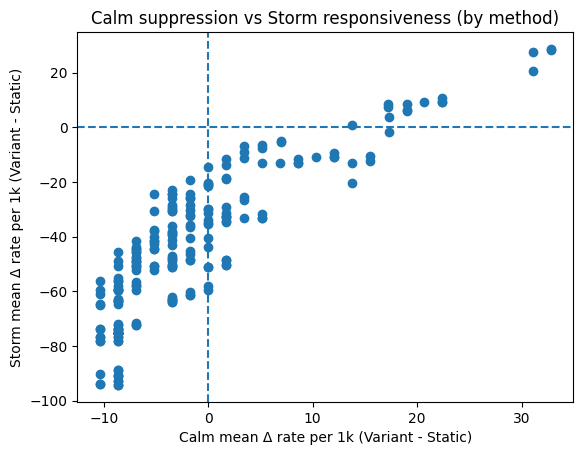

In [7]:
plt.figure()
plt.scatter(score_df['calm_mean_Δ_rate'], score_df['storm_mean_Δ_rate'])
plt.axvline(0.0, linestyle='--')
plt.axhline(0.0, linestyle='--')
plt.xlabel('Calm mean Δ rate per 1k (Variant - Static)')
plt.ylabel('Storm mean Δ rate per 1k (Variant - Static)')
plt.title('Calm suppression vs Storm responsiveness (by method)')
plt.show()

## 6. Shortlist Top 3

In [8]:
# Expect: top15_combos has at least ['method','composite_score'] (already sorted desc)

FAMILIES = {
    "adaptive": r"(?:^|_)adaptive(?:_|$)",
    "capped":   r"(?:^|_)CAPPED[_-]?minmax",   # e.g. CAPPED_minmax_...
    "dwell":    r"(?:^|_)DWELL[_-]?PATTERN",   # e.g. DWELL_PATTERN_...
}

def best_of_family(df: pd.DataFrame, label: str, pattern: str):
    sub = df[df["method"].str.contains(pattern, case=True, regex=True)]
    if sub.empty:
        return None
    row = sub.sort_values("composite_score", ascending=False).head(1).copy()
    row.insert(0, "family", label)
    return row

rows = [best_of_family(top15_combos, fam, pat) for fam, pat in FAMILIES.items()]
shortlist = pd.concat([r for r in rows if r is not None], ignore_index=True)

shortlist

,family,method,calm_mean_Δ_rate,storm_mean_Δ_rate,global_Δ_total,global_pct_dev,calm_score,storm_score,global_score,composite_score
0,adaptive,adaptive_IFw1080q010_AEw720q950,-5.190311,-24.293541,-541,-0.109603,0.605769,0.776224,0.879070,0.708042
1,capped,CAPPED_minmax_IFw336q030_AEw336q975,-3.472139,-28.541591,-1129,-0.228728,0.579327,0.738928,0.781395,0.675087
2,dwell,DWELL_PATTERN_IFw336q030_AEw336q950,-3.460208,-29.926633,-1217,-0.246556,0.507212,0.715618,0.725581,0.632255


## 6b Prepare shortlisted data

In [9]:
CSV_SHORTLIST  = BASE / "SHORTLIST_complete_scores_thresholds_confidence.csv"

print("Files exist:", CSV_SHORTLIST.exists())

Files exist: True


In [10]:
df_s = pd.read_csv(CSV_SHORTLIST, parse_dates=["timestamp"])
df_s.head(3)

,timestamp,temperature_2m,surface_pressure,wind_speed_10m,precipitation,temperature_2m_z,surface_pressure_z,wind_r,precip_log,precip_z_12h,...,hybrid_label_pattern_dwell3__wIF336h_qIF030__wAE336h_qAE950,conf__adaptive__wIF1080h_qIF010__wAE720h_qAE950,conf__adaptive__wIF336h_qIF030__wAE336h_qAE975,conf__adaptive__wIF336h_qIF030__wAE336h_qAE950,conf__blend_cap020__wIF1080h_qIF010__wAE720h_qAE950,conf__blend_cap020__wIF336h_qIF030__wAE336h_qAE975,conf__blend_cap020__wIF336h_qIF030__wAE336h_qAE950,conf__pattern_dwell3__wIF1080h_qIF010__wAE720h_qAE950,conf__pattern_dwell3__wIF336h_qIF030__wAE336h_qAE975,conf__pattern_dwell3__wIF336h_qIF030__wAE336h_qAE950
0,2017-03-02 23:00:00,5.2,1008.1,12.6,0.0,-0.368721,-0.129419,-0.073710,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2017-03-03 00:00:00,5.1,1007.6,12.4,0.0,-0.397814,-0.169181,-0.173770,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2017-03-03 01:00:00,5.6,1007.0,12.7,0.0,-0.250480,-0.216915,-0.216393,0.0,0.0,...,NaN,1.000000e-09,1.000000e-09,1.000000e-09,NaN,NaN,NaN,NaN,NaN,NaN


In [22]:
df_s.columns

Index(['timestamp', 'temperature_2m', 'surface_pressure', 'wind_speed_10m',
       'precipitation', 'temperature_2m_z', 'surface_pressure_z', 'wind_r',
       'precip_log', 'precip_z_12h', 'precip_z_24h', 'hour', 'hour_sin',
       'hour_cos', 'month', 'month_sin', 'month_cos', 'if_score',
       'is_if_anomaly', 'used_in_lstm_training', 'lstm_score',
       'is_lstm_anomaly', 'anomaly_label',
       'if_adaptive_thresh__w1080_q010__wIF1080h_qIF010__wAE720h_qAE950',
       'is_if_adaptive__w1080_q010__wIF1080h_qIF010__wAE720h_qAE950',
       'lstm_adaptive_thresh__w720_q950__wIF1080h_qIF010__wAE720h_qAE950',
       'is_lstm_adaptive__w720_q950__wIF1080h_qIF010__wAE720h_qAE950',
       'hybrid_label_adaptive__wIF1080h_qIF010__wAE720h_qAE950',
       'if_adaptive_thresh__w336_q030__wIF336h_qIF030__wAE336h_qAE975',
       'is_if_adaptive__w336_q030__wIF336h_qIF030__wAE336h_qAE975',
       'lstm_adaptive_thresh__w336_q975__wIF336h_qIF030__wAE336h_qAE975',
       'is_lstm_adaptive__w336_q97

In [11]:
s_columns = [
    'timestamp',
    'temperature_2m',
    'surface_pressure',
    'wind_speed_10m',
    'precipitation',
    'if_score',
    'is_if_anomaly',
    'lstm_score',
    'is_lstm_anomaly',
    'anomaly_label',

    'if_adaptive_thresh__w1080_q010__wIF1080h_qIF010__wAE720h_qAE950',
    'is_if_adaptive__w1080_q010__wIF1080h_qIF010__wAE720h_qAE950',
    'lstm_adaptive_thresh__w720_q950__wIF1080h_qIF010__wAE720h_qAE950',
    'is_lstm_adaptive__w720_q950__wIF1080h_qIF010__wAE720h_qAE950',
    'hybrid_label_adaptive__wIF1080h_qIF010__wAE720h_qAE950',

    'if_adaptive_thresh__w336_q030__wIF336h_qIF030__wAE336h_qAE975_blend_cap020',
    'lstm_adaptive_thresh__w336_q975__wIF336h_qIF030__wAE336h_qAE975_blend_cap020',
    'is_if_adaptive__w336_q030_blend_flag_cap020',
    'is_lstm_adaptive__w336_q975_blend_flag_cap020',
    'hybrid_label_blend_cap020__wIF336h_qIF030__wAE336h_qAE975',

    'is_lstm_adaptive__w336_q950_blend_flag_cap020_dwell3',
    'hybrid_label_pattern_dwell3__wIF336h_qIF030__wAE336h_qAE950',

    'conf__adaptive__wIF1080h_qIF010__wAE720h_qAE950',
    'conf__blend_cap020__wIF336h_qIF030__wAE336h_qAE975',
    'conf__pattern_dwell3__wIF336h_qIF030__wAE336h_qAE950'
]

In [12]:
df_s_trimmed = df_s[s_columns].copy()

In [13]:
# Define your evaluation windows

# Small eval window processor helper
def _process_eval_windows(eval_windows):
    return [(entry['label'], entry['start'], entry['end']) for entry in eval_windows]

PROCESSED_EVAL_WINDOWS = _process_eval_windows(EVAL_WINDOWS)
# Build a mask for all date ranges
mask = pd.Series(False, index=df_s_trimmed.index)
for _, start, end in PROCESSED_EVAL_WINDOWS:
    mask |= (df_s_trimmed['timestamp'] >= start) & (df_s_trimmed['timestamp'] <= end)

# Apply the mask
filtered_df = df_s_trimmed[mask]
filtered_df

,timestamp,temperature_2m,surface_pressure,wind_speed_10m,precipitation,if_score,is_if_anomaly,lstm_score,is_lstm_anomaly,anomaly_label,...,if_adaptive_thresh__w336_q030__wIF336h_qIF030__wAE336h_qAE975_blend_cap020,lstm_adaptive_thresh__w336_q975__wIF336h_qIF030__wAE336h_qAE975_blend_cap020,is_if_adaptive__w336_q030_blend_flag_cap020,is_lstm_adaptive__w336_q975_blend_flag_cap020,hybrid_label_blend_cap020__wIF336h_qIF030__wAE336h_qAE975,is_lstm_adaptive__w336_q950_blend_flag_cap020_dwell3,hybrid_label_pattern_dwell3__wIF336h_qIF030__wAE336h_qAE950,conf__adaptive__wIF1080h_qIF010__wAE720h_qAE950,conf__blend_cap020__wIF336h_qIF030__wAE336h_qAE975,conf__pattern_dwell3__wIF336h_qIF030__wAE336h_qAE950
19201,2019-05-12 00:00:00,6.3,1026.8,6.6,0.0,0.213070,False,0.478000,False,Normal,...,0.039163,0.730020,False,False,NaN,False,NaN,NaN,NaN,NaN
19202,2019-05-12 01:00:00,6.2,1027.4,6.8,0.0,0.219354,False,0.510787,False,Normal,...,0.039163,0.730020,False,False,NaN,False,NaN,NaN,NaN,NaN
19203,2019-05-12 02:00:00,6.0,1028.1,7.3,0.0,0.226359,False,0.531229,False,Normal,...,0.039163,0.730020,False,False,NaN,False,NaN,NaN,NaN,NaN
19204,2019-05-12 03:00:00,4.8,1028.7,8.5,0.0,0.236746,False,0.549142,False,Normal,...,0.039246,0.730020,False,False,NaN,False,NaN,NaN,NaN,NaN
19205,2019-05-12 04:00:00,3.7,1029.1,9.3,0.0,0.228755,False,0.557842,False,Normal,...,0.039246,0.730020,False,False,NaN,False,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43677,2022-02-24 20:00:00,4.0,1012.4,20.2,0.0,0.264829,False,0.375209,False,Normal,...,0.005644,0.785961,False,False,NaN,False,NaN,NaN,NaN,NaN
43678,2022-02-24 21:00:00,3.7,1013.0,20.4,0.0,0.248219,False,0.387732,False,Normal,...,0.005644,0.785961,False,False,NaN,False,NaN,NaN,NaN,NaN
43679,2022-02-24 22:00:00,3.5,1013.3,20.8,0.0,0.250790,False,0.390306,False,Normal,...,0.005644,0.785961,False,False,NaN,False,NaN,NaN,NaN,NaN
43680,2022-02-24 23:00:00,3.4,1013.6,22.3,0.0,0.257821,False,0.391336,False,Normal,...,0.005644,0.785961,False,False,NaN,False,NaN,NaN,NaN,NaN


## 7) Plot suite — Static vs Top-3 variants

The **following cells** produce:

- Stacks: 4 raw variables with anomaly markers (single legend for types + confidence).
- Window densities: grouped bars of Point/Pattern/Compound per method per window (+ CSV).
- Confidence timelines (adaptive only): confidence line with anomaly overlays.
- Threshold drift: IF/AE scores vs thresholds (static or rolling) with exceedance dots.
- Global density (df_g): counts and rates/1k by method & anomaly type.

**Data & rules:**

Anomaly labels: trusted hybrid_label_*; static hybrid rebuilt from is_if_anomaly & is_lstm_anomaly.

Confidence ∈ [0,1] → marker size/alpha (low → small/faint; high → big/opaque).

Windows are inclusive [start, end].

**Outputs:**
- results/final/figures/
- eval_windows_static_vs_top3_adaptive_variants/
- anomaly_density/<window>/ and anomaly_density/global_df_g/
- confidence_timelines/
- threshold_drift/

In [14]:
# -------------------------------------------------------------------
# Paths
# -------------------------------------------------------------------
if "BASE" not in globals():
    # Fallback if BASE wasn't defined earlier in the notebook
    BASE = Path().resolve().parent / "results" / "final"

FIGURES_OUT_DIR = BASE / "figures"
SUBDIRS = {
    "stacks":            FIGURES_OUT_DIR / "eval_windows_static_vs_top3_adaptive_variants",
    "anomaly_density":   FIGURES_OUT_DIR / "anomaly_density",
    "threshold_drift":   FIGURES_OUT_DIR / "threshold_drift",
    "confidence":        FIGURES_OUT_DIR / "confidence_timelines",
}
for _p in SUBDIRS.values():
    _p.mkdir(parents=True, exist_ok=True)

# -------------------------------------------------------------------
# Data columns / variables
# -------------------------------------------------------------------
RAW_VARS = ["temperature_2m", "surface_pressure", "wind_speed_10m", "precipitation"]

# # Four evaluation windows (inclusive)
# EVAL_WINDOWS = [
#     ("Calm 2019",   "2019-05-12", "2019-05-24"),
#     ("Calm 2020",   "2020-04-19", "2020-04-25"),
#     ("CiaraDennis", "2020-02-05", "2020-02-20"),
#     ("Eunice",      "2022-02-12", "2022-02-25"),
# ]

# Static thresholds (for drift plots)
STATIC_IF_THR = 0.03304385848702787
STATIC_AE_THR = 0.6425

# -------------------------------------------------------------------
# Methods — Top-3 variants (plus static)
#   - Use ONLY trusted hybrid_label_* columns
#   - Static is rebuilt from flags (is_if_anomaly / is_lstm_anomaly)
# -------------------------------------------------------------------
METHODS = {
    "static": {
        "label_source": "rebuild_static",  # special
        "conf_col": None,
        "pretty": "static",
        "token":  "baseline",
        "thr_if": "STATIC_CONST",
        "thr_ae": "STATIC_CONST",
    },
    "adaptive_IFw1080q010_AEw720q950": {
        "label_col": "hybrid_label_adaptive__wIF1080h_qIF010__wAE720h_qAE950",
        "conf_col":  "conf__adaptive__wIF1080h_qIF010__wAE720h_qAE950",
        "pretty":    "adaptive",
        "token":     "IFw1080q010_AEw720q950",
        "thr_if":    "if_adaptive_thresh__w1080_q010__wIF1080h_qIF010__wAE720h_qAE950",
        "thr_ae":    "lstm_adaptive_thresh__w720_q950__wIF1080h_qIF010__wAE720h_qAE950",
    },
    "CAPPED_minmax_IFw336q030_AEw336q975": {
        "label_col": "hybrid_label_blend_cap020__wIF336h_qIF030__wAE336h_qAE975",
        "conf_col":  "conf__blend_cap020__wIF336h_qIF030__wAE336h_qAE975",
        "pretty":    "capped-minmax",
        "token":     "IFw336q030_AEw336q975",
        "thr_if":    "if_adaptive_thresh__w336_q030__wIF336h_qIF030__wAE336h_qAE975_blend_cap020",
        "thr_ae":    "lstm_adaptive_thresh__w336_q975__wIF336h_qIF030__wAE336h_qAE975_blend_cap020",
    },
    "DWELL_PATTERN_IFw336q030_AEw336q950": {
        "label_col": "hybrid_label_pattern_dwell3__wIF336h_qIF030__wAE336h_qAE950",
        "conf_col":  "conf__pattern_dwell3__wIF336h_qIF030__wAE336h_qAE950",
        "pretty":    "dwell",
        "token":     "IFw336q030_AEw336q950",
        "thr_if":    None,  # dwell is post-process; thresholds unchanged/unused in drift plot
        "thr_ae":    None,
    },
}
METHOD_ORDER = list(METHODS.keys())  # consistent drawing order

# -------------------------------------------------------------------
# Styling (consistent across all plots)
# -------------------------------------------------------------------
ANOM_TYPES   = ["Point", "Pattern", "Compound"]
ANOM_COLOURS = {"Point": "#1f77b4", "Pattern": "#ff7f0e", "Compound": "#9467bd"}

SIZE_MIN, SIZE_MAX = 20, 160       # marker sizes (points^2)
ALPHA_MIN, ALPHA_MAX = 0.25, 0.95  # marker alpha bounds
STATIC_DEFAULT_CONF = 0.65         # used when a method has no confidence

STACK_FIGSIZE = (14, 9)

# -------------------------------------------------------------------
# Helpers (reuse in all plotting cells)
# -------------------------------------------------------------------
def slice_inclusive(df: pd.DataFrame, start: str, end: str) -> pd.DataFrame:
    s, e = pd.to_datetime(start), pd.to_datetime(end)
    return df[(df["timestamp"] >= s) & (df["timestamp"] <= e)].copy()

def rebuild_static_hybrid(df: pd.DataFrame) -> pd.Series:
    """Hybrid from static flags; respects pandas nullable booleans."""
    if ("is_if_anomaly" not in df.columns) or ("is_lstm_anomaly" not in df.columns):
        return pd.Series(pd.NA, index=df.index, dtype="string")
    if_flag = df["is_if_anomaly"].astype("boolean")
    ae_flag = df["is_lstm_anomaly"].astype("boolean")
    lab = pd.Series(pd.NA, index=df.index, dtype="string")
    both = (if_flag == True) & (ae_flag == True)
    only_if = (if_flag == True) & (ae_flag != True)
    only_ae = (ae_flag == True) & (if_flag != True)
    return lab.mask(only_if, "Point").mask(only_ae, "Pattern").mask(both, "Compound")

def get_labels_and_conf(df: pd.DataFrame, method_key: str):
    """Return (labels, confidence) for a method on a given df slice."""
    spec = METHODS[method_key]
    if spec.get("label_source") == "rebuild_static":
        labels = rebuild_static_hybrid(df)
        conf = None
    else:
        lab_col = spec["label_col"]
        labels = df[lab_col] if lab_col in df.columns else pd.Series(pd.NA, index=df.index, dtype="string")
        conf_col = spec.get("conf_col")
        conf = df[conf_col] if (conf_col and conf_col in df.columns) else None
    labels = labels.astype("string").str.title()
    return labels, conf

def masks_from_label(labels: pd.Series) -> dict[str, pd.Series]:
    s = labels.fillna("None").astype(str).str.title()
    return {k: (s == k) for k in ANOM_TYPES}

def conf_to_size_alpha(conf: pd.Series | None, fallback: float = STATIC_DEFAULT_CONF):
    """Map confidence in [0,1] → (size, alpha). Low conf → small/faint; high → big/opaque."""
    if conf is None:
        conf = pd.Series(fallback, index=dfw.index)  # dfw will be defined in plotting cells
    conf = conf.clip(0, 1)
    size = SIZE_MIN + conf * (SIZE_MAX - SIZE_MIN)
    alpha = ALPHA_MIN + conf * (ALPHA_MAX - ALPHA_MIN)
    return size, alpha

def scale_size(conf: pd.Series | None):
    if conf is None:
        return None
    c = conf.clip(lower=0, upper=1).fillna(0.0)
    return (SIZE_MIN + (SIZE_MAX - SIZE_MIN) * c).astype(float)

def scale_alpha(conf: pd.Series | None):
    if conf is None:
        return None
    c = conf.clip(lower=0, upper=1).fillna(0.0)
    return (ALPHA_MIN + (ALPHA_MAX - ALPHA_MIN) * c).astype(float)

def window_id(label: str, start: str, end: str) -> str:
    """Match the counting scripts' format for cross-checks."""
    return f"{label.replace(' ', '_')}_{pd.to_datetime(start).date()}_{pd.to_datetime(end).date()}"

def title_for(window_label: str, method_key: str) -> str:
    """Format: 'Calm 2019 - dwell - IFw336q030_AEw336q950' (or '- baseline' for static)."""
    spec = METHODS[method_key]
    pretty = spec.get("pretty", method_key)
    token  = spec.get("token", "baseline")
    return f"{window_label} - {pretty} - {token}"

def method_color_map() -> dict:
    """Consistent bar colors for density plots (method-level)."""
    return {"static": "#4e79a7", "adaptive_IFw1080q010_AEw720q950": "#f28e2b",
            "CAPPED_minmax_IFw336q030_AEw336q975": "#59a14f",
            "DWELL_PATTERN_IFw336q030_AEw336q950": "#e15759"}

def anomaly_legend_handles():
    return [
        Line2D([0],[0], marker='o', linestyle='', markersize=8,
               markerfacecolor=ANOM_COLOURS["Point"],    markeredgecolor='none', label='Point (IF)'),
        Line2D([0],[0], marker='o', linestyle='', markersize=8,
               markerfacecolor=ANOM_COLOURS["Pattern"],  markeredgecolor='none', label='Pattern (AE)'),
        Line2D([0],[0], marker='o', linestyle='', markersize=8,
               markerfacecolor=ANOM_COLOURS["Compound"], markeredgecolor='none', label='Compound (IF+AE)'),
    ]

def confidence_legend_handles():
    return [
        Line2D([0],[0], marker='o', linestyle='', color='k',
               markersize=np.sqrt(SIZE_MIN), alpha=ALPHA_MIN, label='Low confidence'),
        Line2D([0],[0], marker='o', linestyle='', color='k',
               markersize=np.sqrt((SIZE_MIN + SIZE_MAX)/2), alpha=(ALPHA_MIN + ALPHA_MAX)/2, label='Med confidence'),
        Line2D([0],[0], marker='o', linestyle='', color='k',
               markersize=np.sqrt(SIZE_MAX), alpha=ALPHA_MAX, label='High confidence'),
    ]

In [18]:
# PLOT STACKS
OUT_DIR = SUBDIRS["stacks"]

def _stack_one(dfw: pd.DataFrame, window_label: str, method_key: str):
    """Draw one figure: 4 stacked raw variables + anomaly markers for a method."""
    # --- labels & confidence ---
    labels, conf = get_labels_and_conf(dfw, method_key)
    sizes = scale_size(conf)
    alphas = scale_alpha(conf)
    if sizes is None:
        sizes = pd.Series((SIZE_MIN + SIZE_MAX) / 2.0, index=dfw.index)
    if alphas is None:
        alphas = pd.Series((ALPHA_MIN + ALPHA_MAX) / 2.0, index=dfw.index)

    # --- figure scaffold ---
    fig, axes = plt.subplots(len(RAW_VARS), 1, figsize=STACK_FIGSIZE, sharex=True)
    if len(RAW_VARS) == 1:
        axes = [axes]

    for ax, var in zip(axes, RAW_VARS):
        # base line
        if var not in dfw.columns:
            ax.text(0.5, 0.5, f"[missing] {var}", ha="center", va="center", transform=ax.transAxes)
            ax.set_ylabel(var)
            continue

        ax.plot(dfw["timestamp"], dfw[var], linewidth=1.0, color="#333333")
        ax.set_ylabel(var)
        ax.grid(True, alpha=0.25)

        # anomalies by type (fixed colours; per-point alpha/size from confidence)
        for a_type in ANOM_TYPES:
            sel = (labels == a_type) & dfw[var].notna()
            if not sel.any():
                continue

            x = dfw.loc[sel, "timestamp"]
            y = dfw.loc[sel, var]
            s = sizes.loc[sel].astype(float)
            a = alphas.loc[sel].astype(float)

            base = ANOM_COLOURS[a_type]
            cols = [mcolors.to_rgba(base, float(ai)) for ai in a]
            ax.scatter(x, y, s=s, c=cols, edgecolors="none")

    axes[-1].set_xlabel("timestamp")

    # title & legend (single legend on top axis)
    title = title_for(window_label, method_key)
    axes[0].set_title(title, loc="left", fontsize=13, fontweight="bold")

    handles = anomaly_legend_handles() + [Line2D([], [], linestyle='')] + confidence_legend_handles()
    axes[0].legend(handles=handles, loc="upper right", frameon=False, fontsize=9,
                   title="Anomaly types & confidence", ncols=1)

    fig.tight_layout()
    pretty = METHODS[method_key].get("pretty", method_key)
    token  = METHODS[method_key].get("token", "baseline")
    fname = f"{window_label}__{pretty}__{token}.png".replace(" ", "_")
    fig.savefig(OUT_DIR / fname, dpi=160)
    plt.close(fig)

# === run for all windows × methods using df_s_trimmed ===
made = 0
for (wl, ws, we) in PROCESSED_EVAL_WINDOWS:
    dfw = slice_inclusive(df_s_trimmed, ws, we)
    for mk in METHOD_ORDER:
        _stack_one(dfw, wl, mk)
        made += 1

print(f"[ok] Stacked plots → {OUT_DIR.resolve()}  (made {made} figs)")

[ok] Stacked plots → C:\Users\jerry\Dropbox\JEREMIAH\MY_STUDIES\DATA_SCIENCE\University_of_Greenwich\Year2\COMP1885 - Individual Project\CODE\comp1885-adaptive-thresholding\results\final\figures\eval_windows_static_vs_top3_adaptive_variants  (made 16 figs)


In [37]:
# DESNITY PLOTS
# - static  → rebuilt from is_if_anomaly & is_lstm_anomaly
# - adaptive/capped/dwell → the trusted hybrid_label_* columns in METHODS
# - windows are inclusive; counts only for ["Point","Pattern","Compound"]

OUT_DIR = SUBDIRS["anomaly_density"]
METHOD_COLORS = method_color_map()
ANOM_ORDER = ANOM_TYPES  # ["Point","Pattern","Compound"]


def _counts_for_method(dfw: pd.DataFrame, method_key: str) -> dict:
    """Return dict with counts for Point/Pattern/Compound for a given method/window slice."""
    labels, _ = get_labels_and_conf(dfw, method_key)
    if labels is None or labels.empty:
        return {k: 0 for k in ANOM_ORDER}
    # Only count canonical types; ignore NA/other strings
    s = labels.dropna().astype(str).str.title()
    return {k: int((s == k).sum()) for k in ANOM_ORDER}


def _plot_window_density(window_label: str, start_date: str, end_date: str):
    dfw = slice_inclusive(df_s_trimmed, start_date, end_date)

    # Build counts table (method_key, pretty, counts...)
    rows = []
    for mk in METHOD_ORDER:
        spec = METHODS[mk]
        cnt = _counts_for_method(dfw, mk)
        rows.append({"method_key": mk, "pretty": spec["pretty"], **cnt})
    counts_df = pd.DataFrame(rows)

    # Save tidy CSV for audit
    tidy_rows = []
    for _, r in counts_df.iterrows():
        for a in ANOM_ORDER:
            tidy_rows.append({
                "window": window_label, "method_key": r["method_key"], "method": r["pretty"],
                "anomaly_type": a, "count": int(r[a])
            })
    out_csv_dir = OUT_DIR / window_label.replace(" ", "_")
    out_csv_dir.mkdir(parents=True, exist_ok=True)
    pd.DataFrame(tidy_rows).to_csv(out_csv_dir / "anomaly_density_counts.csv", index=False)

    # Plot grouped bars
    x = np.arange(len(ANOM_ORDER))
    width = 0.2
    fig, ax = plt.subplots(figsize=(12, 5.2))

    for i, mk in enumerate(METHOD_ORDER):
        row = counts_df[counts_df["method_key"] == mk]
        if row.empty:
            continue
        pretty = row["pretty"].iloc[0]
        color = METHOD_COLORS.get(mk, "#777777")
        counts = [int(row[a].values[0]) for a in ANOM_ORDER]
        ax.bar(x + (i - (len(METHOD_ORDER) - 1) / 2) * width, counts, width=width,
               label=pretty, color=color)

    ax.set_xticks(x, ANOM_ORDER)
    ax.set_ylabel("Count")
    ax.set_title(f"{window_label} – Anomaly density by type & method")
    ax.grid(True, axis="y", alpha=0.3)
    ax.legend(title="Method")

    fig.tight_layout()
    fig.savefig(out_csv_dir / f"{window_label.replace(' ', '_')}__anomaly_density.png", dpi=160)
    plt.close(fig)


# Run for all evaluation windows
for (wl, ws, we) in PROCESSED_EVAL_WINDOWS:
    _plot_window_density(wl, ws, we)

print(f"[ok] Density plots → {OUT_DIR.resolve()}")

[ok] Density plots → C:\Users\jerry\Dropbox\JEREMIAH\MY_STUDIES\DATA_SCIENCE\University_of_Greenwich\Year2\COMP1885 - Individual Project\CODE\comp1885-adaptive-thresholding\results\final\figures\anomaly_density


In [38]:
# CONFIDENCE SCORES TIMELINES
# Uses helpers from the params cell: slice_inclusive, get_labels_and_conf,
# ANOM_TYPES, ANOM_COLOURS, scale_size, scale_alpha, title_for, SUBDIRS.

import matplotlib.colors as mcolors

OUT_DIR = SUBDIRS["confidence"]


def _conf_timeline_one(dfw: pd.DataFrame, window_label: str, method_key: str):
    """Plot confidence timeline for one method; overlay anomalies with size/alpha from confidence."""
    labels, conf = get_labels_and_conf(dfw, method_key)
    if conf is None or conf.dropna().empty:
        # no confidence available for this method — skip
        return

    # Normalise
    labels = labels.astype("string").str.title()
    conf = conf.clip(0, 1)

    # Visual scaling
    sizes = scale_size(conf)  # [SIZE_MIN..SIZE_MAX]
    alphas = scale_alpha(conf)  # [ALPHA_MIN..ALPHA_MAX]

    fig, ax = plt.subplots(figsize=(12, 4.2))
    ax.plot(dfw["timestamp"], conf, linewidth=1.2, label="confidence")
    ax.set_ylim(-0.02, 1.02)
    ax.set_ylabel("Confidence [0..1]")
    ax.set_xlabel("timestamp")
    ax.grid(True, alpha=0.3)

    # Overlay anomalies by type, reusing fixed colours and per-point alpha/size
    for a_type in ANOM_TYPES:
        m = (labels == a_type) & conf.notna()
        if not m.any():
            continue
        x = dfw.loc[m, "timestamp"]
        y = conf.loc[m]
        s = sizes.loc[m].astype(float)
        a = alphas.loc[m].astype(float)
        base = ANOM_COLOURS[a_type]
        cols = [mcolors.to_rgba(base, float(ai)) for ai in a]
        ax.scatter(x, y, s=s, c=cols, edgecolors="none", label=a_type)

    # Title & legend
    t = title_for(window_label, method_key)
    ax.set_title(f"{t} — confidence timeline", loc="left", fontsize=12.5, fontweight="bold")
    handles = [Line2D([0], [0], marker='o', linestyle='', markersize=8,
                      markerfacecolor=ANOM_COLOURS[k], markeredgecolor='none', label=k)
               for k in ANOM_TYPES]
    ax.legend(handles=handles, title="Anomaly types", loc="upper right", frameon=False, fontsize=9)

    fig.tight_layout()
    spec = METHODS[method_key]
    pretty = spec.get("pretty", method_key)
    token = spec.get("token", "baseline")
    fname = f"{window_label}__{pretty}__{token}__confidence.png".replace(" ", "_")
    fig.savefig(OUT_DIR / fname, dpi=160)
    plt.close(fig)


# Run for all windows × methods (skip static since it has no confidence)
made = 0
for (wl, ws, we) in PROCESSED_EVAL_WINDOWS:
    dfw = slice_inclusive(df_s_trimmed, ws, we)
    for mk in METHOD_ORDER:
        if METHODS[mk].get("conf_col"):  # only methods with confidence columns
            _conf_timeline_one(dfw, wl, mk)
            made += 1

print(f"[ok] Confidence timelines → {OUT_DIR.resolve()}  (made {made} figs)")


[ok] Confidence timelines → C:\Users\jerry\Dropbox\JEREMIAH\MY_STUDIES\DATA_SCIENCE\University_of_Greenwich\Year2\COMP1885 - Individual Project\CODE\comp1885-adaptive-thresholding\results\final\figures\confidence_timelines  (made 12 figs)


In [39]:
# MODEL SCORES VS THRESHOLDS (STATIC + ADAPTIVE VARIANTS)
# Uses params/helpers from the [params] cell:
#   - slice_inclusive, METHODS, METHOD_ORDER, SUBDIRS, STATIC_IF_THR, STATIC_AE_THR, title_for
# Plots two rows (IF, AE). Shows rolling thresholds when available; static as horizontal lines.

OUT_DIR = SUBDIRS.get("threshold_drift", (FIGURES_OUT_DIR / "threshold_drift"))
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Optional: overlay anomaly markers at exceedances (per-model flags)
SHOW_FLAG_MARKERS = True
FLAG_STYLE = dict(marker='o', linestyle='', color='crimson', alpha=0.6, s=24, edgecolors='none')

# Known per-method flag columns (to mark exceedances on drift plots)
# - static flags come from the baseline columns already in df_s_trimmed
# - adaptive/capped flags mirror the specific top-3 variants we’re plotting
FLAG_COLS = {
    "static": {
        "if_flag": "is_if_anomaly",
        "ae_flag": "is_lstm_anomaly",
    },
    "adaptive_IFw1080q010_AEw720q950": {
        "if_flag": "is_if_adaptive__w1080_q010__wIF1080h_qIF010__wAE720h_qAE950",
        "ae_flag": "is_lstm_adaptive__w720_q950__wIF1080h_qIF010__wAE720h_qAE950",
    },
    "CAPPED_minmax_IFw336q030_AEw336q975": {
        "if_flag": "is_if_adaptive__w336_q030_blend_flag_cap020",
        "ae_flag": "is_lstm_adaptive__w336_q975_blend_flag_cap020",
    },
    # Dwell is a post-process on AE flags; thresholds same as capped but we skip drift for dwell
}


def _threshold_drift_one(dfw: pd.DataFrame, window_label: str, method_key: str):
    spec = METHODS[method_key]
    thr_if = spec.get("thr_if")
    thr_ae = spec.get("thr_ae")

    # If neither model has thresholds (e.g., dwell), skip
    if not (thr_if or thr_ae):
        return

    fig, axes = plt.subplots(2, 1, figsize=(12.5, 6.2), sharex=True)
    ax_if, ax_ae = axes

    # --- IF panel ---
    ax_if.plot(dfw["timestamp"], dfw["if_score"], label="IF score", linewidth=1.05, color="#2c3e50")
    if thr_if == "STATIC_CONST":
        ax_if.axhline(STATIC_IF_THR, color="#d62728", linestyle="--", linewidth=1.2,
                      label=f"IF static θ = {STATIC_IF_THR:.4f}")
    elif thr_if and thr_if in dfw.columns:
        ax_if.plot(dfw["timestamp"], dfw[thr_if], label="IF threshold", linewidth=1.25, color="#d62728")
    else:
        ax_if.text(0.01, 0.9, "[IF threshold N/A]", transform=ax_if.transAxes, fontsize=9, color="#666")
    ax_if.set_ylabel("IF score")
    ax_if.grid(True, alpha=0.3)
    ax_if.legend(loc="upper right", frameon=False, fontsize=9)

    # Optional exceedance markers (IF)
    if SHOW_FLAG_MARKERS:
        if method_key in FLAG_COLS and FLAG_COLS[method_key].get("if_flag") in dfw.columns:
            m = dfw[FLAG_COLS[method_key]["if_flag"]].astype("boolean") == True
            if m.any():
                ax_if.scatter(dfw.loc[m, "timestamp"], dfw.loc[m, "if_score"], **FLAG_STYLE)

    # --- AE panel ---
    ax_ae.plot(dfw["timestamp"], dfw["lstm_score"], label="AE score", linewidth=1.05, color="#2c3e50")
    if thr_ae == "STATIC_CONST":
        ax_ae.axhline(STATIC_AE_THR, color="#d62728", linestyle="--", linewidth=1.2,
                      label=f"AE static θ = {STATIC_AE_THR:.4f}")
    elif thr_ae and thr_ae in dfw.columns:
        ax_ae.plot(dfw["timestamp"], dfw[thr_ae], label="AE threshold", linewidth=1.25, color="#d62728")
    else:
        ax_ae.text(0.01, 0.9, "[AE threshold N/A]", transform=ax_ae.transAxes, fontsize=9, color="#666")
    ax_ae.set_ylabel("AE score")
    ax_ae.set_xlabel("timestamp")
    ax_ae.grid(True, alpha=0.3)
    ax_ae.legend(loc="upper right", frameon=False, fontsize=9)

    # Optional exceedance markers (AE)
    if SHOW_FLAG_MARKERS:
        if method_key in FLAG_COLS and FLAG_COLS[method_key].get("ae_flag") in dfw.columns:
            m = dfw[FLAG_COLS[method_key]["ae_flag"]].astype("boolean") == True
            if m.any():
                ax_ae.scatter(dfw.loc[m, "timestamp"], dfw.loc[m, "lstm_score"], **FLAG_STYLE)

    # Title
    t = title_for(window_label, method_key)
    fig.suptitle(f"{t} — threshold drift", y=0.98, fontsize=13, fontweight="bold")
    fig.tight_layout(rect=[0.02, 0.03, 0.98, 0.96])

    pretty = spec.get("pretty", method_key);
    token = spec.get("token", "baseline")
    fname = f"{window_label}__{pretty}__{token}__threshold_drift.png".replace(" ", "_")
    fig.savefig(OUT_DIR / fname, dpi=160)
    plt.close(fig)


# Run across windows × methods (skip dwell which has no explicit thresholds in our shortlist)
made = 0
for (wl, ws, we) in PROCESSED_EVAL_WINDOWS:
    dfw = slice_inclusive(df_s_trimmed, ws, we)
    for mk in METHOD_ORDER:
        if METHODS[mk].get("thr_if") or METHODS[mk].get("thr_ae"):
            _threshold_drift_one(dfw, wl, mk)
            made += 1

print(f"[ok] Threshold drift plots → {OUT_DIR.resolve()}  (made {made} figs)")


[ok] Threshold drift plots → C:\Users\jerry\Dropbox\JEREMIAH\MY_STUDIES\DATA_SCIENCE\University_of_Greenwich\Year2\COMP1885 - Individual Project\CODE\comp1885-adaptive-thresholding\results\final\figures\threshold_drift  (made 12 figs)


In [40]:
# GLOBAL ANOMALY DENSITY COUNTS

# Relies on the **params** cell for:
#   - METHODS (incl. 'static' pretty name), METHOD_ORDER (['static', + 3 variants])
#   - ANOM_TYPES (['Point','Pattern','Compound'])
#   - method_color_map(), FIGURES_OUT_DIR, SUBDIRS
#
# df_g schema assumed (already loaded above):
#   ['method','anomaly_type','count_adaptive','count_static','diff_abs','diff_pct','valid_n']

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUT_DIR = (SUBDIRS.get("anomaly_density", FIGURES_OUT_DIR / "anomaly_density")) / "global_df_g"
OUT_DIR.mkdir(parents=True, exist_ok=True)

METHOD_COLORS = method_color_map()
ANOM_ORDER = ANOM_TYPES


def _static_counts_from_df_g(df_g: pd.DataFrame) -> pd.DataFrame:
    """Extract global static counts per anomaly_type (should be constant across methods)."""
    s = (df_g.groupby("anomaly_type", as_index=False)["count_static"]
         .max()  # static counts are replicated per method; any consistent aggregator is fine
         .rename(columns={"count_static": "count"}))
    s["method_key"] = "static"
    s["pretty"] = METHODS["static"]["pretty"]
    # valid_n is the number of valid rows globally (same for all rows in df_g)
    s["valid_n"] = int(df_g["valid_n"].max())
    return s[["method_key", "pretty", "anomaly_type", "count", "valid_n"]]


def _adaptive_counts_from_df_g(df_g: pd.DataFrame, method_key: str) -> pd.DataFrame:
    """Extract global adaptive counts for one method per anomaly_type."""
    sub = df_g[df_g["method"] == method_key].copy()
    if sub.empty:
        return pd.DataFrame(columns=["method_key", "pretty", "anomaly_type", "count", "valid_n"])
    # count_adaptive already aggregated globally per anomaly type
    a = (sub[["anomaly_type", "count_adaptive", "valid_n"]]
         .rename(columns={"count_adaptive": "count"}))
    a["method_key"] = method_key
    a["pretty"] = METHODS.get(method_key, {}).get("pretty", method_key)
    # ensure stable column order
    return a[["method_key", "pretty", "anomaly_type", "count", "valid_n"]]


def build_global_density_df(df_g: pd.DataFrame, method_keys: list[str]) -> pd.DataFrame:
    """Return tidy table: one row per (method_key, anomaly_type)."""
    rows = []
    # Static baseline
    if "static" in method_keys:
        rows.append(_static_counts_from_df_g(df_g))
    # Adaptive variants
    for mk in method_keys:
        if mk == "static":
            continue
        rows.append(_adaptive_counts_from_df_g(df_g, mk))
    out = pd.concat(rows, ignore_index=True)
    # Normalise anomaly_type casing/order and compute rates
    out["anomaly_type"] = out["anomaly_type"].astype(str).str.title()
    out = out[out["anomaly_type"].isin(ANOM_ORDER)]
    out["count"] = out["count"].astype(int)
    out["valid_n"] = out["valid_n"].astype(int)
    out["rate_per_1k"] = out["count"] / out["valid_n"] * 1000.0
    # keep only requested order
    out["method_key"] = pd.Categorical(out["method_key"], METHOD_ORDER, ordered=True)
    out = out.sort_values(["method_key", "anomaly_type"]).reset_index(drop=True)
    return out


method_keys = [mk for mk in METHOD_ORDER if mk in (["static"] + list(df_g["method"].unique()))]
gdf = build_global_density_df(df_g, method_keys)
gdf.to_csv(OUT_DIR / "global_anomaly_density_from_df_g.csv", index=False)

# --- Plot grouped bars: raw counts ---
x = np.arange(len(ANOM_ORDER))
width = 0.2
fig, ax = plt.subplots(figsize=(12, 5.2))

for i, mk in enumerate(method_keys):
    sub = gdf[gdf["method_key"] == mk]
    if sub.empty:
        print(f"[warn] no df_g rows for method '{mk}'")
        continue
    counts = [int(sub.loc[sub["anomaly_type"] == a, "count"].sum()) for a in ANOM_ORDER]
    color = METHOD_COLORS.get(mk, "#777777")
    label = METHODS.get(mk, {}).get("pretty", mk)
    ax.bar(x + (i - (len(method_keys) - 1) / 2) * width, counts, width=width, label=label, color=color)

ax.set_xticks(x, ANOM_ORDER)
ax.set_ylabel("Count (global)")
ax.set_title("Global anomaly density by type & method (df_g)")
ax.grid(True, axis="y", alpha=0.3)
ax.legend(title="Method")

fig.tight_layout()
fig.savefig(OUT_DIR / "global_anomaly_density_counts_df_g.png", dpi=160)
plt.close(fig)

# --- Plot grouped bars: rate per 1k ---
fig, ax = plt.subplots(figsize=(12, 5.2))

for i, mk in enumerate(method_keys):
    sub = gdf[gdf["method_key"] == mk]
    if sub.empty:
        continue
    rates = [float(sub.loc[sub["anomaly_type"] == a, "rate_per_1k"].sum()) for a in ANOM_ORDER]
    color = METHOD_COLORS.get(mk, "#777777")
    label = METHODS.get(mk, {}).get("pretty", mk)
    ax.bar(x + (i - (len(method_keys) - 1) / 2) * width, rates, width=width, label=label, color=color)

ax.set_xticks(x, ANOM_ORDER)
ax.set_ylabel("Rate per 1k (global)")
ax.set_title("Global anomaly density rate (per 1k) by type & method (df_g)")
ax.grid(True, axis="y", alpha=0.3)
ax.legend(title="Method")

fig.tight_layout()
fig.savefig(OUT_DIR / "global_anomaly_density_rates_per_1k_df_g.png", dpi=160)
plt.close(fig)

print(f"[ok] Global density plots from df_g → {OUT_DIR.resolve()}")


[ok] Global density plots from df_g → C:\Users\jerry\Dropbox\JEREMIAH\MY_STUDIES\DATA_SCIENCE\University_of_Greenwich\Year2\COMP1885 - Individual Project\CODE\comp1885-adaptive-thresholding\results\final\figures\anomaly_density\global_df_g


### COMP 1885 Presentation Visuals

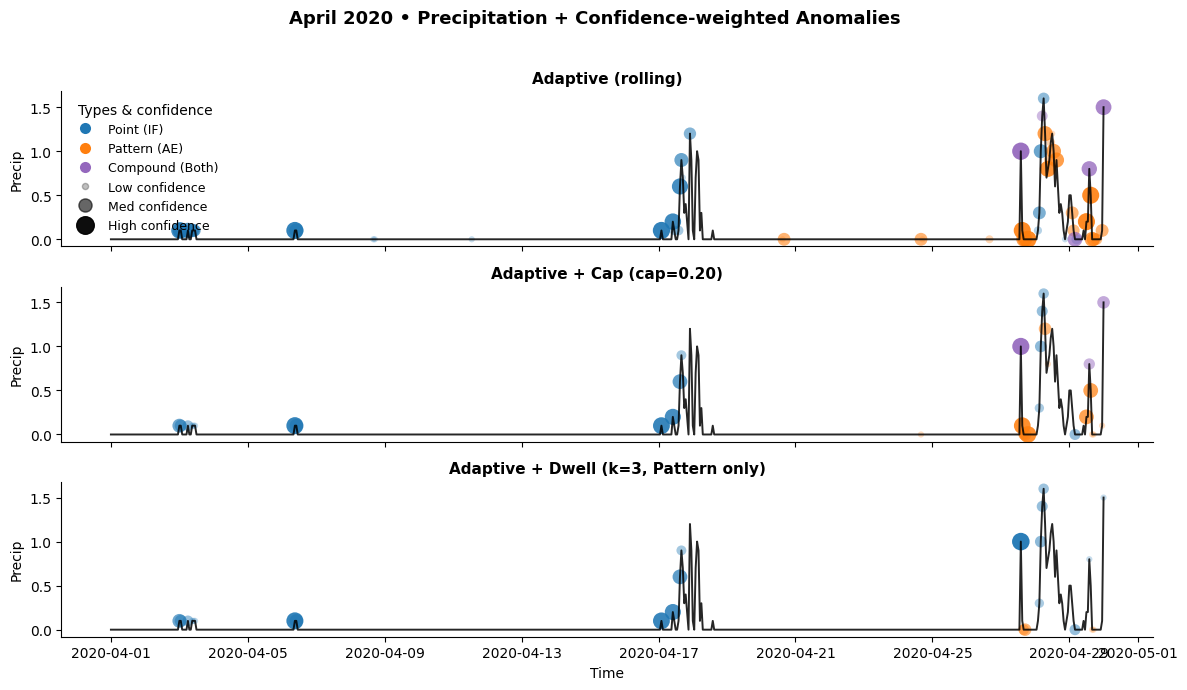

[ok] Saved: C:\Users\jerry\Dropbox\JEREMIAH\MY_STUDIES\DATA_SCIENCE\University_of_Greenwich\Year2\COMP1885 - Individual Project\CODE\comp1885-adaptive-thresholding\results\final\figures\eval_windows_static_vs_top3_adaptive_variants\April 2020__precip_conf_stacks__IFw1080q010_AEw720q950.png


In [40]:
# ===============================================
# Precip + confidence-weighted anomaly markers
# Event_CiaraDennis • IFw1080q010_AEw720q950
# Variants: Adaptive / Capped (cap020) / Dwell (dwell3)
# Requires: df_s with the columns you listed.
# ===============================================
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors

# -------- User inputs (edit if needed) --------
WINDOW_LABEL = "April 2020"
START, END = "2020-04-01", "2020-04-30"
# EVAL_WINDOWS = [
#     ("Calm 2019",   "2019-05-12", "2019-05-24"),
#     ("Calm 2020",   "2020-04-19", "2020-04-25"),
#     ("CiaraDennis", "2020-02-05", "2020-02-20"),
#     ("Eunice",      "2022-02-12", "2022-02-25"),
# This is the exact token used in your df_s column names for this combo
COMBO_TOKEN = "wIF336h_qIF030__wAE336h_qAE975"

# Anomaly type colours (consistent with your notebook)
ANOM_COLOURS = {"Point": "#1f77b4", "Pattern": "#ff7f0e", "Compound": "#9467bd"}

# Marker size/alpha bounds for confidence scaling
SIZE_MIN, SIZE_MAX = 20, 160
ALPHA_MIN, ALPHA_MAX = 0.25, 0.95

# Output directory – reuse your SUBDIRS["stacks"] if present, else fallback
if "SUBDIRS" in globals() and isinstance(SUBDIRS, dict) and "stacks" in SUBDIRS:
    OUT_DIR = Path(SUBDIRS["stacks"])
else:
    OUT_DIR = Path("figures") / "eval_windows_static_vs_top3_adaptive_variants"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# -------- Helpers --------
def _slice(df, start, end):
    s, e = pd.to_datetime(start), pd.to_datetime(end)
    d = df[(df["timestamp"] >= s) & (df["timestamp"] <= e)].copy()
    return d.sort_values("timestamp")

def _norm01(s: pd.Series) -> pd.Series:
    s = pd.to_numeric(s, errors="coerce")
    if s.min() >= 0 and s.max() <= 1:
        return s.fillna(0.0)
    rng = (s.max() - s.min()) or 1.0
    return ((s - s.min()) / rng).fillna(0.0)

def _sizes_alphas(conf: pd.Series):
    c = _norm01(conf)
    sizes = SIZE_MIN + (SIZE_MAX - SIZE_MIN) * c
    alphas = ALPHA_MIN + (ALPHA_MAX - ALPHA_MIN) * c
    return sizes.astype(float), alphas.astype(float)

def _plot_panel(ax, dfw, label_col, conf_col, title):
    # Base precipitation line
    ax.plot(dfw["timestamp"], dfw["precipitation"], color="black", linewidth=1.4, alpha=0.85, label="Precipitation")

    # Prepare labels/conf
    labels = dfw[label_col].astype("string").str.title()
    conf = dfw[conf_col]
    sizes, alphas = _sizes_alphas(conf)

    # Scatter by anomaly type, with confidence-driven alpha/size
    for a_type, base_col in ANOM_COLOURS.items():
        sel = (labels == a_type) & dfw["precipitation"].notna()
        if sel.any():
            x = dfw.loc[sel, "timestamp"]
            y = dfw.loc[sel, "precipitation"]
            s = sizes.loc[sel]
            a = alphas.loc[sel]
            cols = [mcolors.to_rgba(base_col, float(ai)) for ai in a]
            ax.scatter(x, y, s=s, c=cols, edgecolors="none")

    # Clean styling
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_ylabel("Precip")
    ax.grid(False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# -------- Column names (exactly from your df_s index) --------
LABEL_ADAPT = f"hybrid_label_adaptive__{COMBO_TOKEN}"
CONF_ADAPT  = f"conf__adaptive__{COMBO_TOKEN}"

LABEL_CAP   = f"hybrid_label_blend_cap020__{COMBO_TOKEN}"
CONF_CAP    = f"conf__blend_cap020__{COMBO_TOKEN}"

LABEL_DWELL = f"hybrid_label_pattern_dwell3__{COMBO_TOKEN}"
CONF_DWELL  = f"conf__pattern_dwell3__{COMBO_TOKEN}"

required_cols = [
    "timestamp", "precipitation",
    LABEL_ADAPT, CONF_ADAPT,
    LABEL_CAP,   CONF_CAP,
    LABEL_DWELL, CONF_DWELL,
]
missing = [c for c in required_cols if c not in df_s.columns]
if missing:
    raise KeyError(f"Missing in df_s: {missing}")

# -------- Slice to window and plot --------
dfw = _slice(df_s, START, END)

fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)

# 1) Adaptive
_plot_panel(
    axes[0], dfw,
    label_col=LABEL_ADAPT, conf_col=CONF_ADAPT,
    title="Adaptive (rolling)"
)

# 2) Capped (blend cap020)
_plot_panel(
    axes[1], dfw,
    label_col=LABEL_CAP, conf_col=CONF_CAP,
    title="Adaptive + Cap (cap=0.20)"
)

# 3) Dwell (pattern dwell3)
_plot_panel(
    axes[2], dfw,
    label_col=LABEL_DWELL, conf_col=CONF_DWELL,
    title="Adaptive + Dwell (k=3, Pattern only)"
)

axes[-1].set_xlabel("Time")

# Single legend (top-right on first axis)
handles = [
    Line2D([0],[0], marker='o', linestyle='', markersize=8,
           markerfacecolor=ANOM_COLOURS["Point"],   markeredgecolor='none', label='Point (IF)'),
    Line2D([0],[0], marker='o', linestyle='', markersize=8,
           markerfacecolor=ANOM_COLOURS["Pattern"], markeredgecolor='none', label='Pattern (AE)'),
    Line2D([0],[0], marker='o', linestyle='', markersize=8,
           markerfacecolor=ANOM_COLOURS["Compound"], markeredgecolor='none', label='Compound (Both)'),
    # Line2D([], [], linestyle=''),
    Line2D([0],[0], marker='o', linestyle='', color='k',
           markersize=np.sqrt(SIZE_MIN), alpha=ALPHA_MIN, label='Low confidence'),
    Line2D([0],[0], marker='o', linestyle='', color='k',
           markersize=np.sqrt((SIZE_MIN+SIZE_MAX)/2), alpha=(ALPHA_MIN+ALPHA_MAX)/2, label='Med confidence'),
    Line2D([0],[0], marker='o', linestyle='', color='k',
           markersize=np.sqrt(SIZE_MAX), alpha=ALPHA_MAX, label='High confidence'),
]
axes[0].legend(handles=handles, loc="upper left", frameon=False, fontsize=9,
               title="Types & confidence", ncols=1)

suptitle = f"{WINDOW_LABEL} • Precipitation + Confidence-weighted Anomalies"
fig.suptitle(suptitle, fontsize=13, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.96])

# Save + show
outfile = OUT_DIR / f"{WINDOW_LABEL}__precip_conf_stacks__IFw1080q010_AEw720q950.png"
fig.savefig(outfile, dpi=200, bbox_inches="tight")
plt.show()
print(f"[ok] Saved: {outfile.resolve()}")

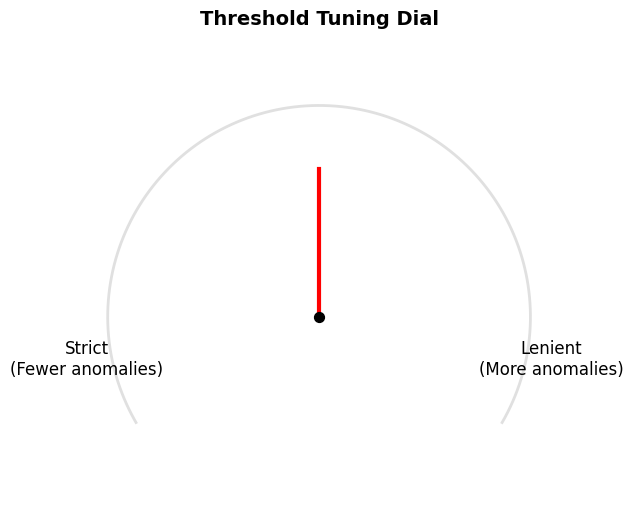

In [51]:
import matplotlib.pyplot as plt
import numpy as np

# --- Create a simple "tuning dial" style mock visual ---

fig, ax = plt.subplots(figsize=(6, 6))

# Draw dial arc
theta = np.linspace(-np.pi/6, 7*np.pi/6, 300)
r = 1.0
x = r * np.cos(theta)
y = r * np.sin(theta)
ax.plot(x, y, color="#E0E0E0", linewidth=2)

# Labels for strict vs lenient
ax.text(-1.1, -0.2, "Strict\n(Fewer anomalies)", ha="center", va="center", fontsize=12)
ax.text(1.1, -0.2, "Lenient\n(More anomalies)", ha="center", va="center", fontsize=12)

# Needle position (midpoint for now)
needle_angle = np.pi/2  # vertical
needle_x = 0.7 * np.cos(needle_angle)
needle_y = 0.7 * np.sin(needle_angle)
ax.plot([0, needle_x], [0, needle_y], color="red", linewidth=3)

# Dial center
ax.scatter(0, 0, color="black", s=50, zorder=5)

# Clean look
ax.axis("equal")
ax.axis("off")
ax.set_title("Threshold Tuning Dial", fontsize=14, fontweight="bold")

plt.show()